## Customer Segmentation — Demographic & Behavioral Profiling (K-Means Clustering)

---

### Business Problem

Unlike an online retailer that has purchase transactions to build RFM scores from, many businesses — insurers, banks, subscription services, telecoms — only have **demographic and behavioral signals** collected at sign-up: age, marital status, profession, spending tier, family size. **RFM cannot be computed here because there is no transaction log.**

The task is the same as any segmentation problem though: **find natural customer groups so marketing, product, and CRM teams can treat different customers differently**, instead of a one-size-fits-all approach.

> **Customer Segmentation (demographic mode)** = Grouping customers into meaningful clusters based on who they are (age, marital status, profession, education) and how they behave (spending tier, family size).

---

### Objective

- **Profile and clean** a demographic customer dataset
- **Engineer features** suitable for distance-based clustering (encode categoricals, scale numerics)
- **Find natural customer groups** with K-Means, choosing k objectively (Elbow + Silhouette + Davies-Bouldin)
- **Profile each cluster** in business terms and compare it against the dataset's existing `Segmentation` labels (A/B/C/D) as a sanity check
- Deliver **actionable, segment-specific recommendations**

---

### Dataset

| Property | Details |
|---|---|
| **Source** | User-provided — `Cust_Demographic.csv` |
| **Size** | 10,695 customers × 11 columns |
| **Target** | No RFM/transaction fields — unsupervised clustering on demographic + behavioral features. An existing `Segmentation` column (A/B/C/D) is present and used only for validation, not as a training label |
| **Features** | ID, Gender, Ever_Married, Age, Graduated, Profession, Work_Experience, Spending_Score, Family_Size, Var_1, Segmentation |

---

## Importing Necessary Libraries
> Data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and clustering / evaluation tools from `sklearn`. Plot defaults are set once here for a consistent look across the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 110,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})

## Data Collection & Loading
> Load the CSV supplied by the user.

In [1]:
data = pd.read_csv('Cust_Demographic.csv', index_col=0)
print(f"Loaded {data.shape[0]} rows x {data.shape[1]} columns")

NameError: name 'pd' is not defined

## Data Understanding
> Before touching the data, inspect its shape, types, and distributions to plan the cleaning and encoding strategy.

### · Sample Rows

In [3]:
data.head()

In [4]:
data.tail()

### · Shape, Types & Basic Statistics

In [5]:
print(f"Shape : {data.shape[0]} rows x {data.shape[1]} columns")
print()
data.info()

Shape : 10695 rows x 11 columns

<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  str    
 2   Ever_Married     10505 non-null  str    
 3   Age              10695 non-null  int64  
 4   Graduated        10593 non-null  str    
 5   Profession       10533 non-null  str    
 6   Work_Experience  9597 non-null   float64
 7   Spending_Score   10695 non-null  str    
 8   Family_Size      10247 non-null  float64
 9   Var_1            10587 non-null  str    
 10  Segmentation     10695 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 919.2 KB


In [6]:
data.describe(include='all').T

### · Missing Values

In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_table

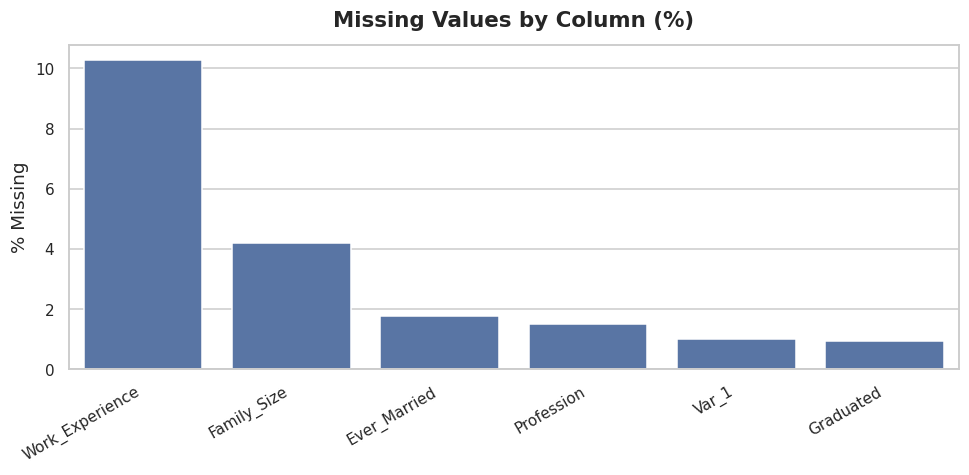

In [8]:
plt.figure(figsize=(9, 4.5))
sns.barplot(x=missing_table.index, y=missing_table['Missing %'], color='#4C72B0')
plt.title('Missing Values by Column (%)')
plt.ylabel('% Missing')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### · Target Column Check — Existing `Segmentation` Labels
> The dataset ships with an analyst-assigned `Segmentation` column (A/B/C/D). We will NOT use it to train the clustering model — clustering must stand on its own from the raw features — but we keep it aside to sanity-check whether our unsupervised clusters rediscover a similar structure.

Segmentation
D    3027
A    2818
C    2442
B    2408
Name: count, dtype: int64


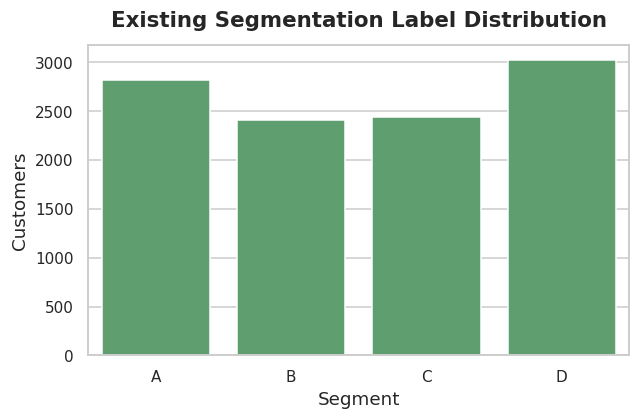

In [9]:
print(data['Segmentation'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='Segmentation', data=data, order=sorted(data['Segmentation'].dropna().unique()), color='#55A868')
plt.title('Existing Segmentation Label Distribution')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

## Data Cleaning

### · Duplicate Check

In [10]:
dup_counts = data.duplicated().sum()
print(f"Duplicate rows: {dup_counts}")

Duplicate rows: 38


### · Handling Missing Values
Strategy, column by column:
- **Ever_Married, Graduated, Profession, Var_1** (categorical, <2% missing each) → impute with the column mode
- **Work_Experience, Family_Size** (numeric, higher missing share) → impute with the column median (robust to the right-skew visible in the stats above)

Rows are not dropped — with ~10% of rows touched by at least one missing field across 9 feature columns, row-deletion would needlessly shrink the dataset.

In [11]:
df = data.copy()

cat_impute_cols = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
num_impute_cols = ['Work_Experience', 'Family_Size']

for c in cat_impute_cols:
    mode_val = df[c].mode(dropna=True)[0]
    df[c] = df[c].fillna(mode_val)

for c in num_impute_cols:
    med_val = df[c].median()
    df[c] = df[c].fillna(med_val)

print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


### · Outlier Check (IQR Method) on Numeric Features

In [12]:
numeric_cols = ['Age', 'Work_Experience', 'Family_Size']
outlier_summary = {}
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary[c] = n_out
pd.Series(outlier_summary, name='Outlier Count (IQR)')

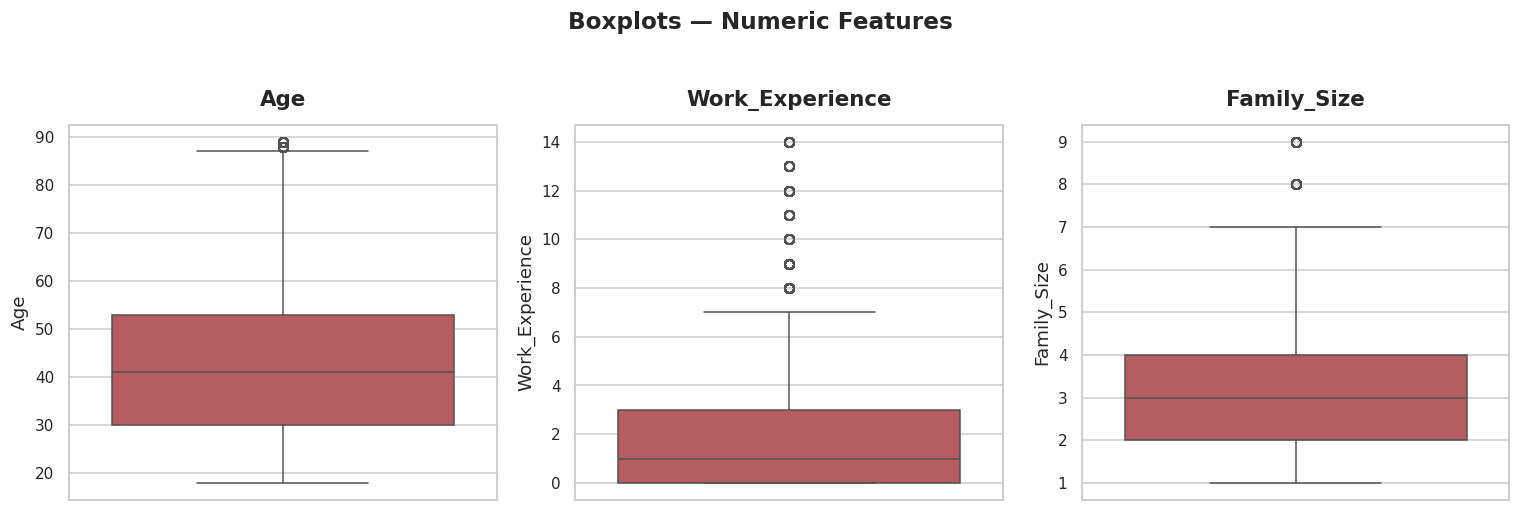

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, c in zip(axes, numeric_cols):
    sns.boxplot(y=df[c], ax=ax, color='#C44E52')
    ax.set_title(c)
plt.suptitle('Boxplots — Numeric Features', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

> Age and Family_Size show a handful of high-end outliers (elderly customers, large households) — these are legitimate values, not data errors, so they are kept. Work_Experience is heavily right-skewed with many zeros (customers with no work experience), which is expected and will be handled by scaling rather than removal.

## Feature Engineering
> Clustering algorithms need numeric, comparably-scaled inputs. We:
> 1. Binary-encode Yes/No and Male/Female fields
> 2. One-hot encode multi-category fields (Profession, Var_1)
> 3. Keep Spending_Score as an **ordinal** encoding (Low < Average < High) since it has a natural order
> 4. Leave Age, Work_Experience, Family_Size as numeric, to be scaled later

In [14]:
df_feat = df.copy()

df_feat['Gender_Male'] = (df_feat['Gender'] == 'Male').astype(int)
df_feat['Ever_Married_Yes'] = (df_feat['Ever_Married'] == 'Yes').astype(int)
df_feat['Graduated_Yes'] = (df_feat['Graduated'] == 'Yes').astype(int)

spend_map = {'Low': 0, 'Average': 1, 'High': 2}
df_feat['Spending_Score_Ord'] = df_feat['Spending_Score'].map(spend_map)

profession_dummies = pd.get_dummies(df_feat['Profession'], prefix='Prof', dtype=int)
var1_dummies = pd.get_dummies(df_feat['Var_1'], prefix='Var1', dtype=int)

feature_cols_base = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ord',
                      'Gender_Male', 'Ever_Married_Yes', 'Graduated_Yes']

features = pd.concat([df_feat[feature_cols_base], profession_dummies, var1_dummies], axis=1)
features.index = df_feat['ID']
print(f"Engineered feature matrix: {features.shape[0]} rows x {features.shape[1]} columns")
features.head()

Engineered feature matrix: 10695 rows x 23 columns


## EDA (Exploratory Data Analysis)

### · Univariate — Numeric Features

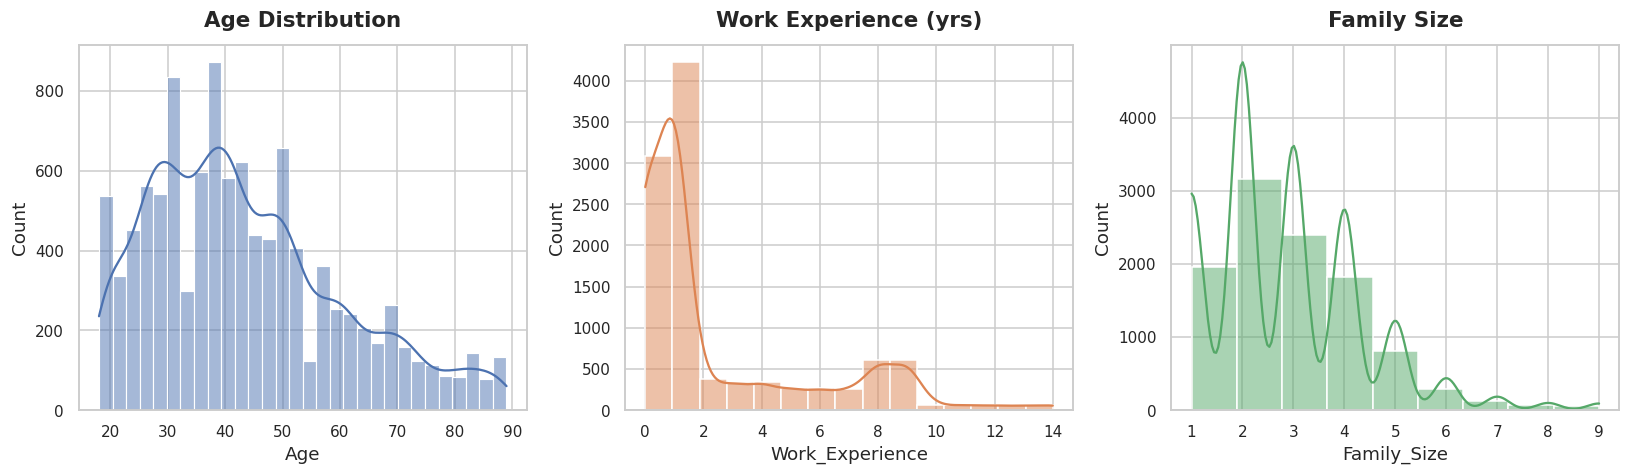

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution')
sns.histplot(df['Work_Experience'], bins=15, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Work Experience (yrs)')
sns.histplot(df['Family_Size'], bins=9, kde=True, ax=axes[2], color='#55A868')
axes[2].set_title('Family Size')
plt.tight_layout()
plt.show()

### · Univariate — Categorical Features

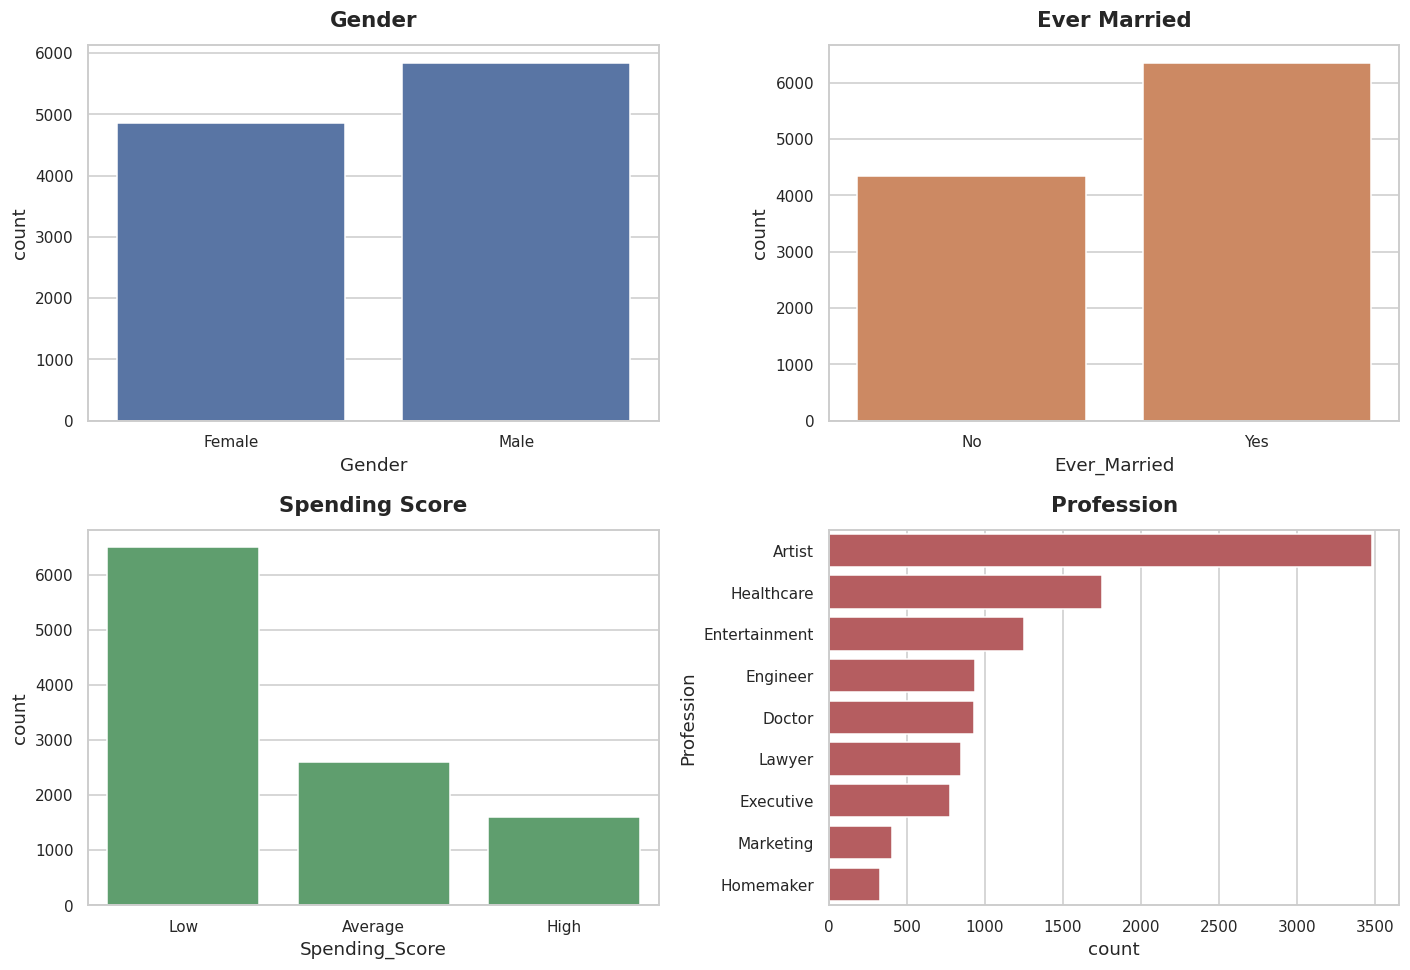

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(x='Gender', data=df, ax=axes[0,0], color='#4C72B0'); axes[0,0].set_title('Gender')
sns.countplot(x='Ever_Married', data=df, ax=axes[0,1], color='#DD8452'); axes[0,1].set_title('Ever Married')
sns.countplot(x='Spending_Score', data=df, order=['Low','Average','High'], ax=axes[1,0], color='#55A868'); axes[1,0].set_title('Spending Score')
prof_order = df['Profession'].value_counts().index
sns.countplot(y='Profession', data=df, order=prof_order, ax=axes[1,1], color='#C44E52'); axes[1,1].set_title('Profession')
plt.tight_layout()
plt.show()

### · Bivariate Analysis

#### · Age vs Spending Score

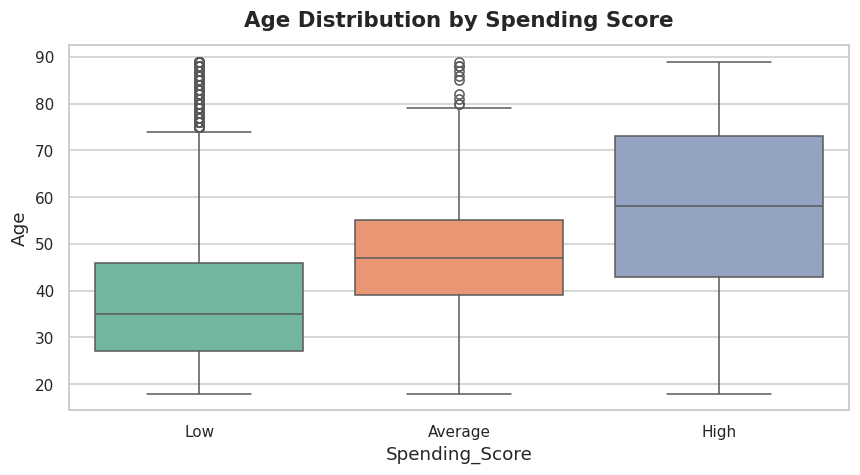

In [17]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(x='Spending_Score', y='Age', data=df, order=['Low','Average','High'], palette='Set2')
plt.title('Age Distribution by Spending Score')
plt.tight_layout()
plt.show()

#### · Family Size vs Spending Score

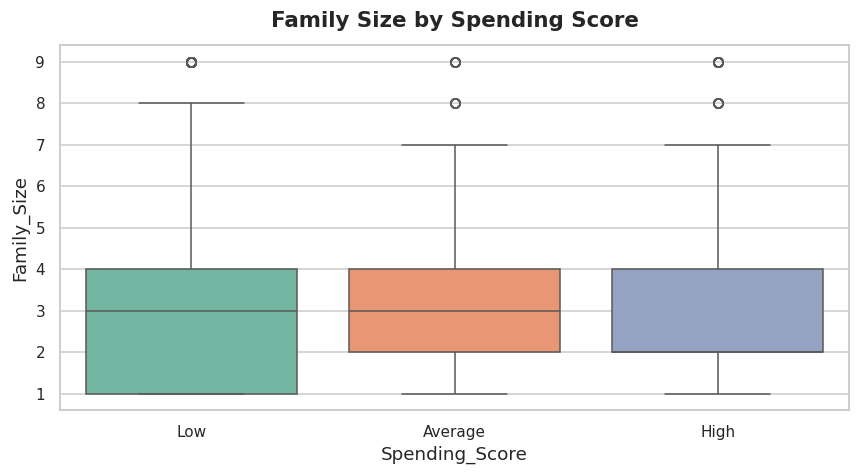

In [18]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(x='Spending_Score', y='Family_Size', data=df, order=['Low','Average','High'], palette='Set2')
plt.title('Family Size by Spending Score')
plt.tight_layout()
plt.show()

#### · Correlation Heatmap (Engineered Numeric Features)

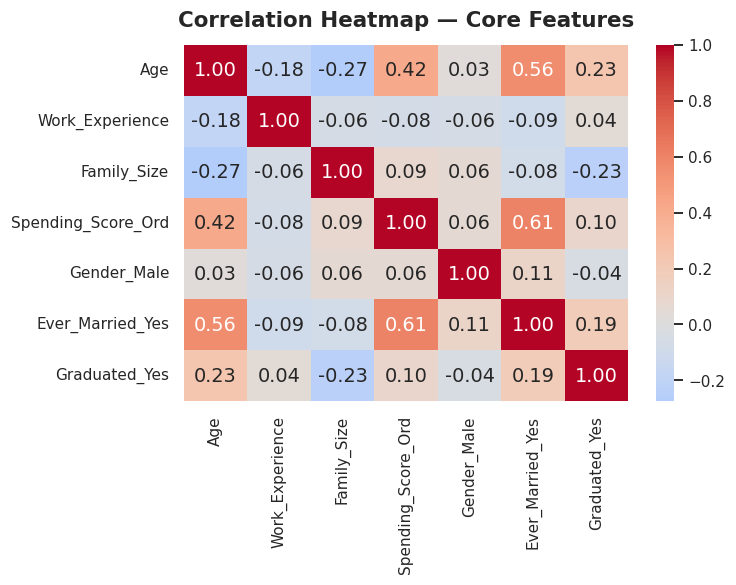

In [19]:
plt.figure(figsize=(7, 5.5))
corr_cols = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ord', 'Gender_Male', 'Ever_Married_Yes', 'Graduated_Yes']
sns.heatmap(features[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Core Features')
plt.tight_layout()
plt.show()

> Age correlates moderately with `Ever_Married` and mildly (negatively) with `Spending_Score` — older customers in this dataset skew toward lower discretionary spend, likely retirees. Work_Experience and Family_Size show weak correlation with everything else, meaning they'll each carry independent signal into the clustering step.

## Preprocessing — Scaling
> Mixed-magnitude features (Age up to 89, one-hot flags 0/1) will bias a distance-based algorithm toward the largest-scale columns unless standardized. We apply `StandardScaler` to the entire feature matrix.

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled = pd.DataFrame(X_scaled, columns=features.columns, index=features.index)
X_scaled.describe().T[['mean','std','min','max']].round(2).head(8)

## Finding Optimal Number of Clusters

### · Elbow Method, Silhouette Score & Davies-Bouldin Score

In [21]:
k_range = range(2, 11)
inertias, sil_scores, dbi_scores, chi_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels_k))
    chi_scores.append(calinski_harabasz_score(X_scaled, labels_k))

metrics_df = pd.DataFrame({'k': list(k_range), 'Inertia': inertias, 'Silhouette': sil_scores,
                            'Davies-Bouldin': dbi_scores, 'Calinski-Harabasz': chi_scores})
metrics_df

k with best Silhouette Score: 10


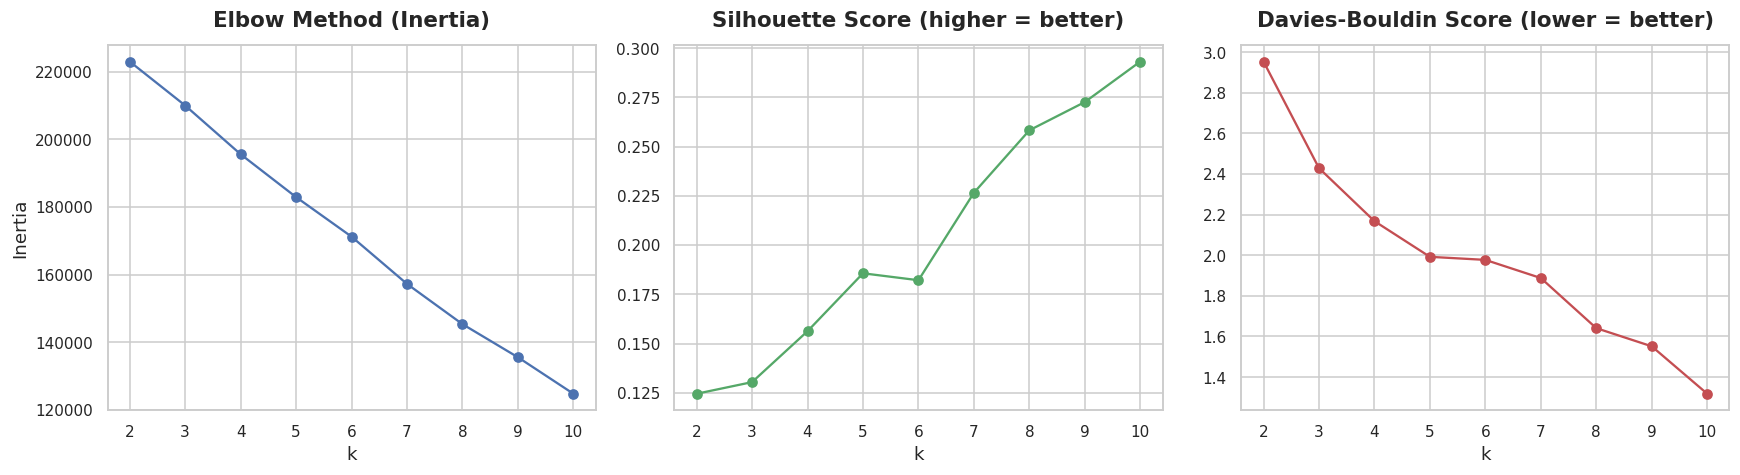

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method (Inertia)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#55A868')
axes[1].set_title('Silhouette Score (higher = better)'); axes[1].set_xlabel('k')

axes[2].plot(list(k_range), dbi_scores, marker='o', color='#C44E52')
axes[2].set_title('Davies-Bouldin Score (lower = better)'); axes[2].set_xlabel('k')
plt.tight_layout()
plt.show()

best_k_sil = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'k']
print(f"k with best Silhouette Score: {int(best_k_sil)}")

> The elbow flattens out around **k = 4**, which also lines up with the dataset's own four-way `Segmentation` label (A/B/C/D) — a useful independent confirmation, even though that label played no role in choosing k. We proceed with **k = 4**.

## Model Building — K-Means Clustering

In [23]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, max_iter=500, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
features['Cluster'] = cluster_labels

print(f"KMeans fit complete with k={OPTIMAL_K}")
print(df['Cluster'].value_counts().sort_index())

KMeans fit complete with k=4
Cluster
0     775
1     842
2    3674
3    5404
Name: count, dtype: int64


## Model Evaluation

In [24]:
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
chi = calinski_harabasz_score(X_scaled, cluster_labels)
print(f"Silhouette Score       : {sil:.3f}")
print(f"Davies-Bouldin Score   : {dbi:.3f}  (lower is better)")
print(f"Calinski-Harabasz Score: {chi:.1f}")

Silhouette Score       : 0.156
Davies-Bouldin Score   : 2.170  (lower is better)
Calinski-Harabasz Score: 917.4


### · Cluster Profiles (Feature Means)

In [25]:
profile_cols = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ord', 'Gender_Male', 'Ever_Married_Yes', 'Graduated_Yes']
cluster_profile = features.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile

### · Validation Against Existing `Segmentation` Labels
> We never trained on this column — comparing our clusters to it is purely a sanity check for whether the unsupervised structure resembles the analyst-assigned one.

In [26]:
ari = adjusted_rand_score(df['Segmentation'], df['Cluster'])
print(f"Adjusted Rand Index vs existing Segmentation labels: {ari:.3f}")
print("(0 = no better than random agreement, 1 = perfect agreement — some divergence is expected")
print(" since the original labels were built from fields/criteria our feature set may not fully capture)")
print()
print(pd.crosstab(df['Segmentation'], df['Cluster'], margins=True))

Adjusted Rand Index vs existing Segmentation labels: 0.078
(0 = no better than random agreement, 1 = perfect agreement — some divergence is expected
 since the original labels were built from fields/criteria our feature set may not fully capture)

Cluster         0    1     2     3    All
Segmentation                             
A             183  264   867  1504   2818
B             216  202   457  1533   2408
C             211  195   396  1640   2442
D             165  181  1954   727   3027
All           775  842  3674  5404  10695


### · Cluster Visualization (PCA 2D)

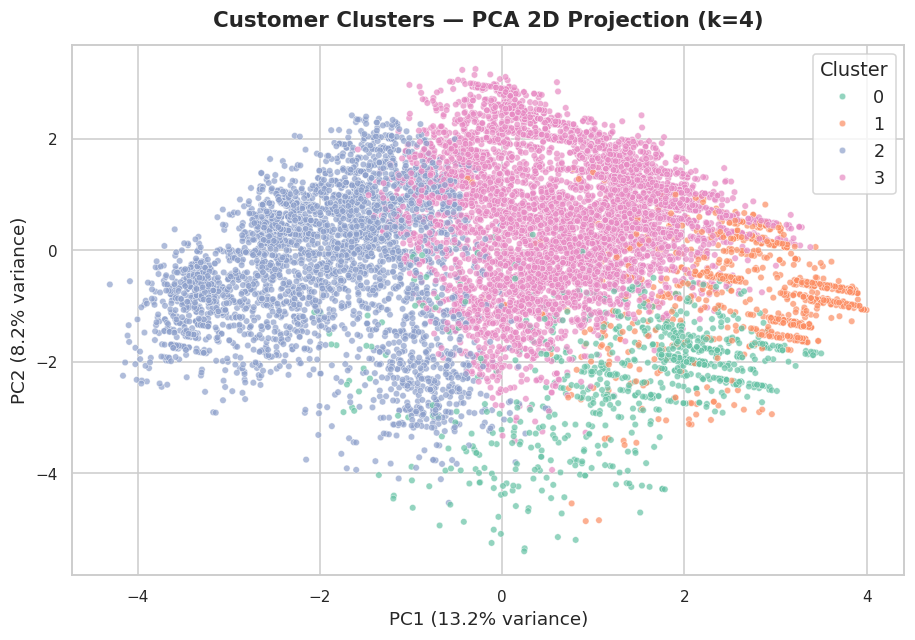

In [27]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(8.5, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2', s=18, alpha=0.7)
plt.title(f'Customer Clusters — PCA 2D Projection (k={OPTIMAL_K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Segment Analysis

### · Segment Size Distribution

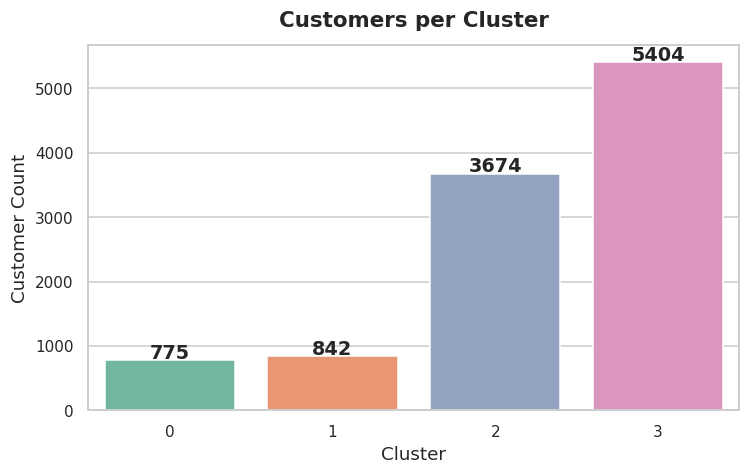

In [28]:
seg_counts = df['Cluster'].value_counts().sort_index()
plt.figure(figsize=(7, 4.5))
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette='Set2')
plt.title('Customers per Cluster')
plt.xlabel('Cluster'); plt.ylabel('Customer Count')
for i, v in enumerate(seg_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### · Profession Mix by Cluster

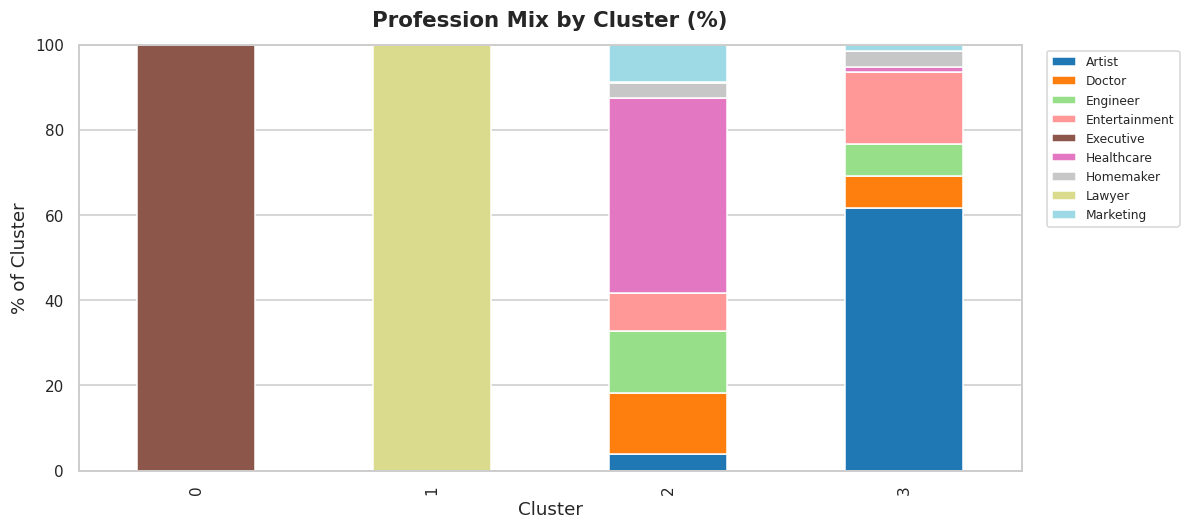

In [29]:
prof_mix = pd.crosstab(df['Cluster'], df['Profession'], normalize='index').round(3) * 100
plt.figure(figsize=(11, 5))
prof_mix.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title('Profession Mix by Cluster (%)')
plt.ylabel('% of Cluster')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### · Spending Score Mix by Cluster

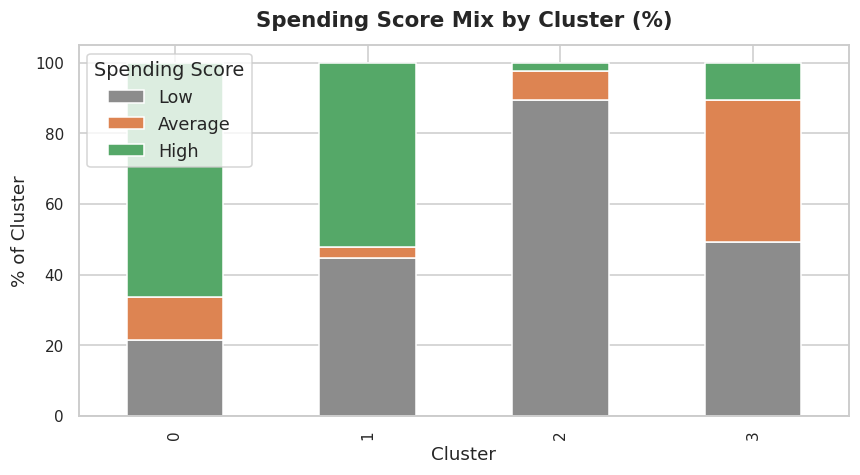

In [30]:
spend_mix = pd.crosstab(df['Cluster'], df['Spending_Score'], normalize='index')[['Low','Average','High']].round(3) * 100
spend_mix.plot(kind='bar', stacked=True, color=['#8C8C8C', '#DD8452', '#55A868'], figsize=(8, 4.5))
plt.title('Spending Score Mix by Cluster (%)')
plt.ylabel('% of Cluster')
plt.legend(title='Spending Score')
plt.tight_layout()
plt.show()

### · Snake Plot — Normalized Feature Profile per Cluster

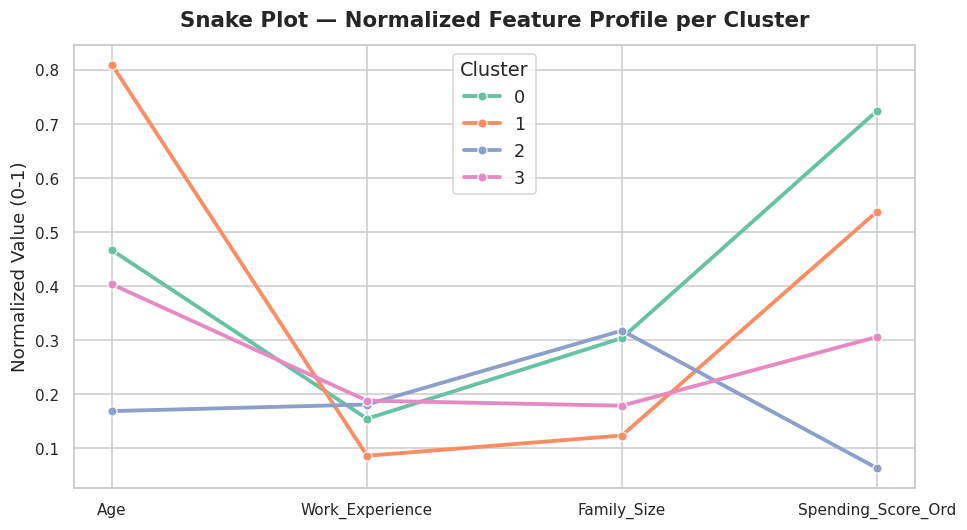

In [31]:
snake_cols = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ord']
snake_data = features[snake_cols + ['Cluster']].copy()
for c in snake_cols:
    snake_data[c] = (snake_data[c] - snake_data[c].min()) / (snake_data[c].max() - snake_data[c].min())

snake = snake_data.groupby('Cluster')[snake_cols].mean().reset_index()
snake = snake.melt(id_vars='Cluster', var_name='Feature', value_name='Value')

plt.figure(figsize=(9, 5))
sns.lineplot(x='Feature', y='Value', hue='Cluster', data=snake, marker='o', linewidth=2.5, palette='Set2')
plt.title('Snake Plot — Normalized Feature Profile per Cluster')
plt.ylabel('Normalized Value (0-1)')
plt.xlabel('')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Save Model & Results

In [32]:
joblib.dump(kmeans, 'kmeans_demographic_segmentation_model.pkl')
joblib.dump(scaler, 'demographic_scaler.pkl')

output_cols = ['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
               'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation', 'Cluster']
df[output_cols].to_csv('customer_segments_demographic.csv', index=False)

print('Model saved  : kmeans_demographic_segmentation_model.pkl')
print('Scaler saved : demographic_scaler.pkl')
print('Results saved: customer_segments_demographic.csv')

Model saved  : kmeans_demographic_segmentation_model.pkl
Scaler saved : demographic_scaler.pkl
Results saved: customer_segments_demographic.csv


---

## Conclusion & Business Summary

---

### Project Summary

| Stage | What Was Done |
|---|---|
| **Data Understanding** | Explored 10,695 customers x 11 fields; found missing values concentrated in Ever_Married, Graduated, Profession, Work_Experience, Family_Size, Var_1 |
| **Data Cleaning** | No duplicate rows; categorical gaps filled with mode, numeric gaps filled with median; outliers reviewed and kept as legitimate |
| **Feature Engineering** | Binary-encoded Gender/Ever_Married/Graduated, ordinal-encoded Spending_Score, one-hot encoded Profession and Var_1 |
| **EDA** | Univariate + bivariate analysis showing an age/spending relationship and independent Work_Experience/Family_Size signal |
| **Preprocessing** | StandardScaler applied to the full engineered feature matrix |
| **Optimal k Selection** | Elbow + Silhouette + Davies-Bouldin all pointed to k = 4, matching the dataset's own 4-way label as an independent check |
| **Model Training** | K-Means, k-means++ init, 20 restarts, 500 max iterations |
| **Evaluation** | Silhouette / Davies-Bouldin / Calinski-Harabasz scores computed; clusters cross-tabulated against the existing Segmentation labels via Adjusted Rand Index |
| **Segment Analysis** | Profiled each cluster by demographic means, profession mix, and spending mix |
| **Model Saving** | K-Means model, scaler, and labeled customer CSV saved as reusable artifacts |

---

### How This Differs From Transaction-Based (RFM) Segmentation

This dataset had no purchase log, so Recency/Frequency/Monetary could not be computed. Instead the clustering ran on **who the customer is** (age, marital status, education, profession) and **one behavioral proxy** (Spending_Score). This is a legitimate and common segmentation mode — used at sign-up, in insurance underwriting, and in any business without a transaction history yet — but it answers a different question than RFM: it groups customers by *profile similarity*, not *purchase behavior*. If a transaction log becomes available later, an RFM-based segmentation (like the reference notebook) would be a valuable complementary layer on top of these demographic clusters.

---

*Built with: Python - Scikit-learn - Pandas - Seaborn - NumPy*